# Imports

In [1]:
%load_ext autoreload
%autoreload 2

from config import *

import gcsfs
import jax
import numpy as np
import pickle
import xarray as xr

from dinosaur import horizontal_interpolation
from dinosaur import spherical_harmonic
from dinosaur import xarray_utils
import neuralgcm

import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker
from matplotlib.gridspec import GridSpec

# Load model

In [2]:
model_name = 'v1/deterministic_1_4_deg.pkl'  #@param ['v1/deterministic_0_7_deg.pkl', 'v1/deterministic_1_4_deg.pkl', 'v1/deterministic_2_8_deg.pkl', 'v1/stochastic_1_4_deg.pkl', 'v1_precip/stochastic_precip_2_8_deg.pkl', 'v1_precip/stochastic_evap_2_8_deg'] {type: "string"}

gcs = gcsfs.GCSFileSystem(token='anon')
with gcs.open(f'gs://neuralgcm/models/{model_name}', 'rb') as f:
  ckpt = pickle.load(f)

model = neuralgcm.PressureLevelModel.from_checkpoint(ckpt)

# Load Initial Conditions

In [4]:
# era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
# full_era5 = xr.open_zarr(
#     era5_path, chunks=None, storage_options=dict(token='anon')
# )

# era5_grid = spherical_harmonic.Grid(
#         latitude_nodes=full_era5.sizes['latitude'],
#         longitude_nodes=full_era5.sizes['longitude'],
#         latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
#         longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
#     )
# regridder = horizontal_interpolation.ConservativeRegridder(
#     era5_grid, model.data_coords.horizontal, skipna=True
# )

# data_inner_steps = 24  # process every 24th hour
# for year in range(1994, 2010):
#     print(f"{year}...", end="")
#     demo_start_time = f'{year}-12-01'
#     demo_end_time = f'{year+1}-02-28'

#     sliced_era5 = (
#         full_era5
#         [model.input_variables + model.forcing_variables]
#         .pipe(
#             xarray_utils.selective_temporal_shift,
#             variables=model.forcing_variables,
#             time_shift='24 hours',
#         )
#         .sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
#         .compute()
#     )

#     eval_era5 = xarray_utils.regrid(sliced_era5, regridder)
#     eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

#     eval_era5.to_netcdf(rf"/glade/campaign/univ/uwas0152/neuralGCM_data/DJF_{year}-{year+1}.nc")
#     del sliced_era5
#     del eval_era5
#     print('\u2713')

# print("Finished")

1994...✓
1995...✓
1996...✓
1997...✓
1998...✓
1999...✓
2000...✓
2001...✓
2002...✓
2003...✓
2004...✓
2005...✓
2006...✓
2007...✓
2008...✓
2009...✓
Finished


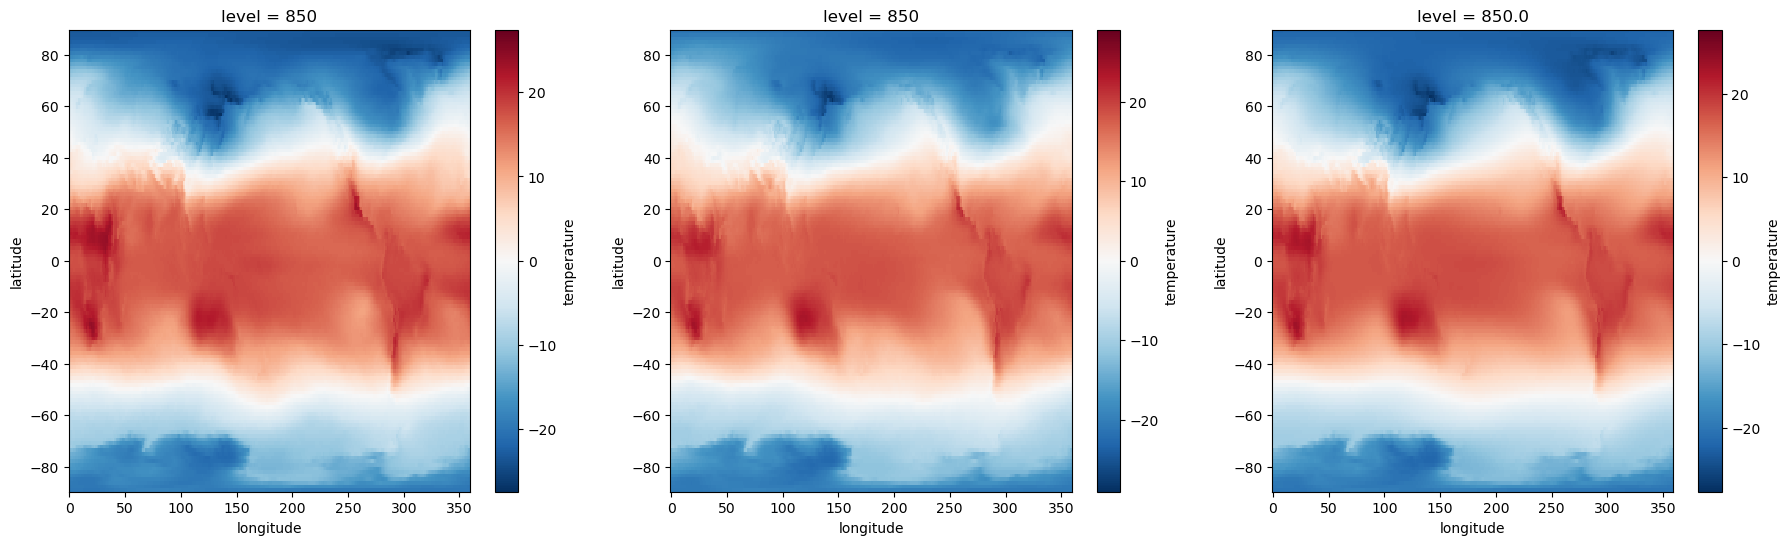

In [22]:
# mean_data = xr.open_dataset(rf"/glade/campaign/univ/uwas0152/neuralGCM_data/thirty_year_DJF_climatology.nc")
# test_data1 = xr.open_dataset(rf"/glade/campaign/univ/uwas0152/neuralGCM_data/DJF_1998-1999.nc")
# test_data2 = xr.open_dataset(rf"/glade/campaign/univ/uwas0152/neuralGCM_data/DJF_2006-2007.nc")
# [fig, ax] = plt.subplots(1, 3, figsize=(22,6))
# (
#     test_data1['temperature'].sel(level=850).mean(dim='time')
#     - test_data1['temperature'].sel(level=850).mean()
# ).plot(x='longitude', ax=ax[0])
# (
#     test_data2['temperature'].sel(level=850).mean(dim='time')
#     - test_data2['temperature'].sel(level=850).mean()
# ).plot(x='longitude', ax=ax[1])
# (
#     mean_data['temperature'].sel(level=850).isel(time=0, drop=True)
#     - mean_data['temperature'].sel(level=850).isel(time=0, drop=True).mean()
# ).plot(x='longitude', ax=ax[2])

# Run model

In [76]:
inner_steps = 1  # save model outputs once every 24 hours
outer_steps = 2 * 1 // inner_steps  # total of 4 days
timedelta = np.timedelta64(1, 'h') * inner_steps
times = (np.arange(outer_steps) * inner_steps)  # time axis in hours

# import pandas as pd

# mean_data = xr.open_dataset(rf"/glade/campaign/univ/uwas0152/neuralGCM_data/thirty_year_DJF_climatology.nc")

# # initialize model state
# inputs = model.inputs_from_xarray(mean_data.isel(time=0, drop=True).expand_dims(time=[pd.Timestamp('2000-01-15')]).isel(time=0))
# input_forcings = model.forcings_from_xarray(mean_data.isel(time=0, drop=True).expand_dims(time=[pd.Timestamp('2000-01-15')]).isel(time=0))
# rng_key = jax.random.key(42)  # optional for deterministic models
# initial_state = model.encode(inputs, input_forcings, rng_key)

In [77]:
ds = neuralgcm.demo.load_data(model.data_coords)
ds_init = ds.isel(time=0)
inputs, forcings = model.data_from_xarray(ds_init)
encoded = model.encode(inputs, forcings, jax.random.key(42))
all_forcings = model.forcings_from_xarray(ds)
# advanced = model.advance(encoded, forcings)
unrolled, predictions = model.unroll(
    encoded,
    all_forcings,
    steps=outer_steps,
    timedelta=timedelta,
    start_with_input=True
)

ValueError: non-integral time-step ratio: duration=Timedelta('0 days 00:30:00') is not a multiple of the internal model timestep 3600 seconds

In [53]:
# import treescope
# treescope.display(advanced)

In [75]:
# treescope.display(encoded)
# type(advanced.state.sim_time)
print(model.sim_time_to_datetime64(encoded.memory.sim_time))
print(model.sim_time_to_datetime64(unrolled.memory.sim_time))
print(model.sim_time_to_datetime64(advanced.memory.sim_time))

1959-01-01T23:58
1959-01-02T11:29
1959-01-02T00:29


In [11]:
# inner_steps = 24  # save model outputs once every 24 hours
# outer_steps = 1 * 24 // inner_steps  # total of 4 days
# timedelta = np.timedelta64(1, 'h') * inner_steps
# times = (np.arange(outer_steps) * inner_steps)  # time axis in hours

# # initialize model state
# inputs = model.inputs_from_xarray(test.isel(time=0))
# input_forcings = model.forcings_from_xarray(test.isel(time=0))
# rng_key = jax.random.key(42)  # optional for deterministic models
# initial_state = model.encode(inputs, input_forcings, rng_key)

# use persistence for forcing variables (SST and sea ice cover)
all_forcings = model.forcings_from_xarray(mean_data.isel(time=0, drop=True).expand_dims(time=[pd.Timestamp('2000-01-15')]).head(time=1))

# # make forecast
# final_state, predictions = model.unroll(
#     initial_state,
#     all_forcings,
#     steps=outer_steps,
#     timedelta=timedelta,
#     start_with_input=True,
# )
# make forecast
advanced_state = model.advance(
    initial_state,
    all_forcings,
    # steps=outer_steps,
    # timedelta=timedelta,
    # start_with_input=True,
)
# predictions_ds = model.data_to_xarray(predictions, times=eval_era5.isel(time=[0]).time+np.timedelta64(1, 'D'))

ValueError: xp and fp must be one-dimensional arrays of equal size

# Mean-state correction

In [8]:
initial_state_ds = eval_era5.isel(time=0)
aligned_initial_state, aligned_predictions = xr.align(initial_state_ds, predictions_ds, join='override')
mean_state_correction = aligned_predictions - aligned_initial_state
corrected_inputs = model.inputs_from_xarray((aligned_predictions - mean_state_correction).isel(time=0))
# corrected_initial_state = model.encode(corrected_inputs, input_forcings, rng_key)

In [2]:
# new_predictions_list = []
# new_predictions_list.append(aligned_predictions)
# for day in range(1, 2, 1):

#     time_start = time.time()
#     previous_state = new_predictions_ds[-1]
#     aligned_previous_state, aligned_mean_state_correction = xr.align(previous_state, mean_state_correction, join='override')
#     corrected_inputs = model.inputs_from_xarray((aligned_previous_state - aligned_mean_state_correction).isel(time=0))
#     corrected_initial_state = model.encode(corrected_inputs, input_forcings, rng_key)

#     time_run = time.time()
#     print(f"Initialization:   {(time_run - time_start):0.2f}s")
#     # make forecast
#     new_final_state, new_predictions = model.unroll(
#         corrected_initial_state,
#         all_forcings,
#         steps=outer_steps,
#         timedelta=timedelta,
#         start_with_input=True,
#     )
#     # print("?")
#     time_append = time.time()
#     print(f"Run Time:         {(time_append - time_run):0.2f}s")
#     new_predictions_list.append(model.data_to_xarray(new_predictions, times=predictions_ds.isel(time=[-1]).time+np.timedelta64(day, 'D')))
#     # new_predictions_list.append(model.data_to_xarray(new_predictions, times=None))
#     time_finish = time.time()
#     print(f"Appending Time:   {(time_finish - time_append):0.2f}s")
#     print(f"Total Loop Time:  {(time_finish - time_start):0.2f}s")

In [121]:

# [aligned_previous_state, aligned_mean_state_correction, aligned_initial_state] = xr.align(*[aligned_previous_state, aligned_mean_state_correction, aligned_initial_state], join='override')
aligned_previous_state - aligned_mean_state_correction
# test_corrected_inputs = model.inputs_from_xarray(
#     (aligned_previous_state - aligned_mean_state_correction + 0.01*aligned_initial_state).isel(time=0)
# )
# test_corrected_initial_state = model.encode(test_corrected_inputs, input_forcings, rng_key)

<xarray.Dataset> Size: 18MB
Dimensions:                              (time: 1, longitude: 187,
                                          latitude: 92, level: 37)
Coordinates:
  * time                                 (time) datetime64[ns] 8B 2018-01-03
  * longitude                            (longitude) float64 1kB 0.0 ... 358.6
  * latitude                             (latitude) float64 736B -88.93 ... 8...
  * level                                (level) int64 296B 1 2 3 ... 975 1000
Data variables:
    v_component_of_wind                  (time, level, longitude, latitude) float32 3MB ...
    temperature                          (time, level, longitude, latitude) float32 3MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 3MB ...
    geopotential                         (time, level, longitude, latitude) float32 3MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 3MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 3MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 3MB ...

In [118]:
# aligned_previous_state - aligned_mean_state_correction + 0.01*aligned_initial_state

<xarray.Dataset> Size: 18MB
Dimensions:                              (time: 1, longitude: 187,
                                          latitude: 92, level: 37)
Coordinates:
  * time                                 (time) datetime64[ns] 8B 2018-01-03
  * longitude                            (longitude) float64 1kB 0.0 ... 358.6
  * latitude                             (latitude) float64 736B -88.93 ... 8...
  * level                                (level) int64 296B 1 2 3 ... 975 1000
Data variables:
    v_component_of_wind                  (time, level, longitude, latitude) float32 3MB ...
    temperature                          (time, level, longitude, latitude) float32 3MB ...
    u_component_of_wind                  (time, level, longitude, latitude) float32 3MB ...
    geopotential                         (time, level, longitude, latitude) float32 3MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 3MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 3MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 3MB ...

# Analyze data

Output directory: /glade/u/home/sressel/thesis-work/python/neuralGCM_analysis/output//
Output filename: 30_year_climatology_initial_condition_run
Not Saving


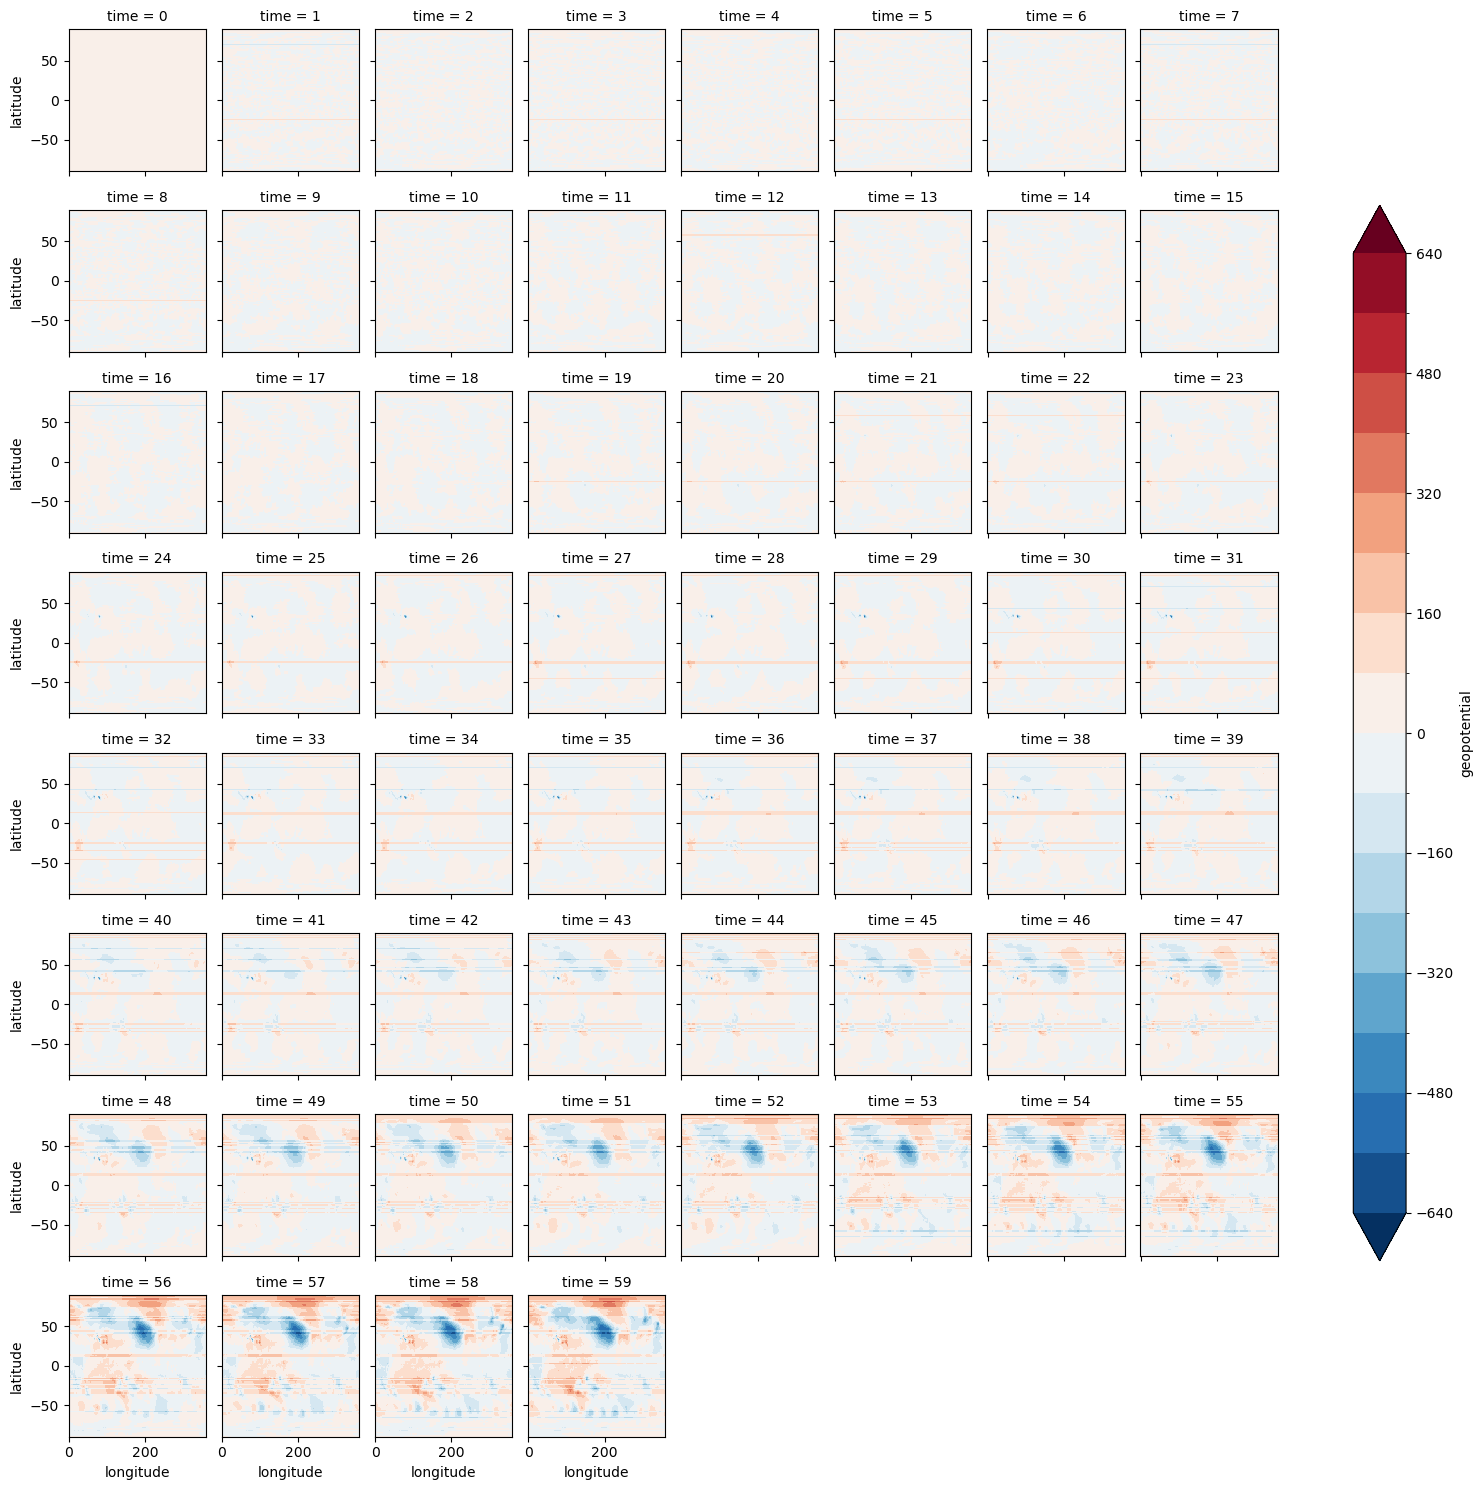

In [78]:
str_width = 40
savefig = False
reload_data = True
# experiment_to_load = "timedelta_test_2_20250828_1237"
# experiment_to_load = "timedelta_test_3_20250828_1314"
# experiment_to_load = "timedelta_test_4_20250828_1321"
# experiment_to_load = "climatology_test_1_20250829_1447"
experiment_to_load = "climatology_test_2_20250829_1503"
if 'data' not in locals() or reload_data:
    # data = xr.load_dataset(f"{data_directory}/multi_day_2018-01-01_deterministic_cf_corrected.nc")
    # data = xr.load_dataset(f"{data_directory}/multi_day_2005-03-21_deterministic_cf_corrected.nc")
    # data = xr.load_dataset(f"{data_directory}/multi_day_2006-01-11_deterministic_cf_corrected.nc")
    # data = xr.load_dataset(f"{data_directory}/perturbed_2006-01-11_deterministic_cf_corrected.nc")
    # data = xr.load_dataset(f"{data_directory}/multi_day_2018-01-01_deterministic_cf_real_time_corrected.nc")
    # data = xr.load_dataset(f"{data_directory}/multi_day_2018-01-01_deterministic_uniform_moisture.nc")
    # data = xr.load_dataset(f"{data_directory}/timedelta_test_2_20250828_1237/model_output.nc")
    data = xr.load_dataset(f"{data_directory}/{experiment_to_load}/model_output.nc")

variable_to_plot = 'geopotential'
p = (
    data[variable_to_plot].sel(level=850)
    # - data[variable_to_plot].sel(level=850).mean(dim=['latitude', 'longitude'])
    - data[variable_to_plot].sel(level=850).isel(time=0)
).plot(
    figsize=(16,len(data[variable_to_plot].time)/4),
    x='longitude',
    y='latitude',
    col='time',
    col_wrap=8,
    # levels=np.linspace(-2e3, 2e3, 21),
    # levels = np.linspace(-10, 10, 21),
    levels = 21,
    extend='both',
    cbar_kwargs={"shrink": 0.75}
)

output_filename = '30_year_climatology_initial_condition_run'
print(f"Output directory: {neuralGCM_output_directory}/")
print(f"Output filename: {output_filename}")
if savefig:
    print(f"{f'Saving...':<{str_width-1}}", end="")
    plt.savefig(
        f"{neuralGCM_output_directory}/{output_filename}.png",
        dpi=500,
        bbox_inches="tight",
    )
    print(rf"{'✔':>1}")
else:
    print("Not Saving")
    plt.show()

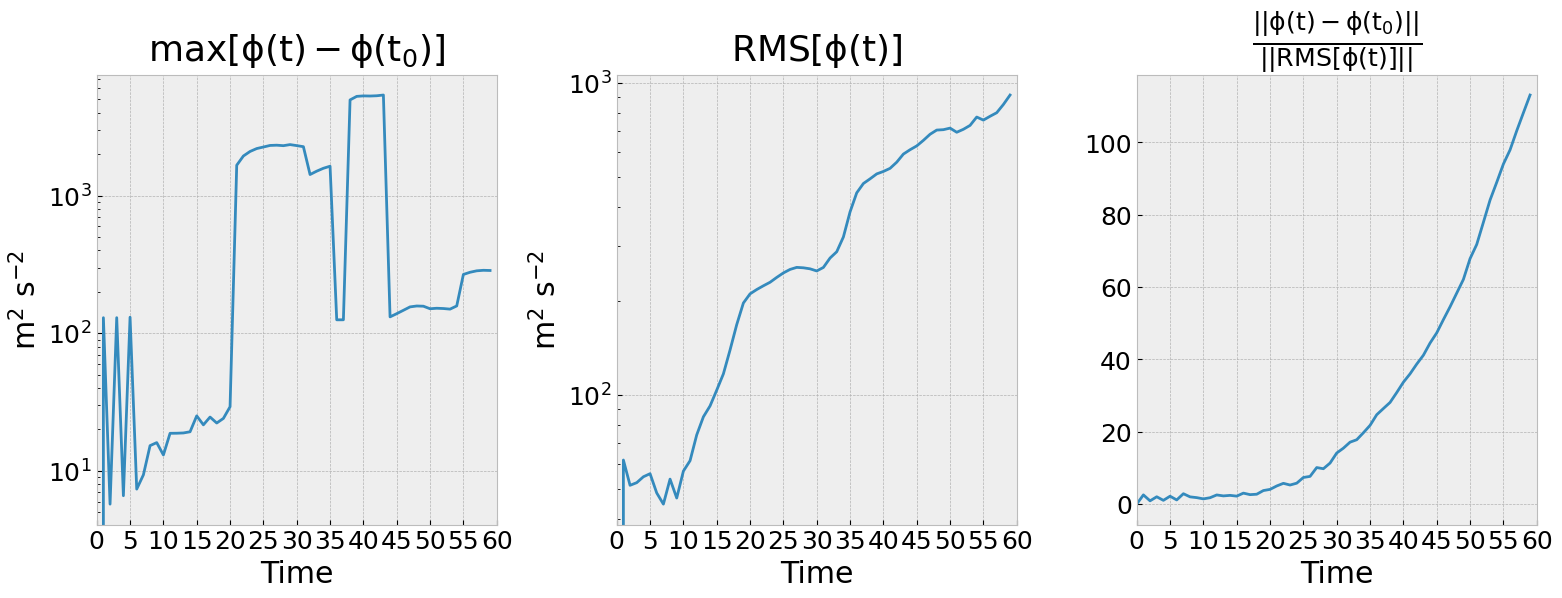

In [79]:
rms = []
ratio_list = []
geopotential_difference_list = []
geopotential_rms = []
spatial_integral = []
geopotential = data['geopotential']#.isel(time=0, drop=True).rename({'new_dim':'time'})
days_to_plot = 60
for day in np.arange(0, days_to_plot, 1):

    geopotential_difference = np.abs(geopotential.isel(time=day) - geopotential.isel(time=0))

    geopotential_rms.append(np.max(np.abs(np.sqrt(((geopotential_difference - geopotential_difference.mean(dim='longitude'))**2).mean(dim='longitude')))))
    rms_deviation = np.sqrt(((geopotential.isel(time=day) - geopotential.isel(time=day).mean(dim='longitude'))**2).mean(dim='longitude'))

    # Peter comment - Compute ratio using integral over latitude and height of both numerator and denomator
    spatial_integral.append(
        geopotential_difference.integrate('latitude').integrate('level').integrate('longitude')
        / rms_deviation.integrate('latitude').integrate('level')
    )

    ratio = geopotential_difference/rms_deviation
    [lev_max, lon_max, lat_max] = np.unravel_index(ratio.argmax(), ratio.shape)
    rms.append(rms_deviation[lev_max, lat_max])
    ratio_list.append(ratio[lev_max, lon_max, lat_max])
    geopotential_difference_list.append(geopotential_difference[lev_max, lon_max, lat_max])
    # geopotential_difference_list.append(zonal_mean_difference[lev_max, lat_max])


plt.style.use('bmh')
plt.rcParams.update({'font.size':18})
plt.rcParams["mathtext.default"] = 'regular'

fig = plt.figure(figsize=(16, 5))
gs = GridSpec(1, 3, figure=fig)
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.1, wspace=0.3)

axes = []
axes.append(fig.add_subplot(gs[0]))
axes.append(fig.add_subplot(gs[1]))
axes.append(fig.add_subplot(gs[2]))

axes[0].set_title(r"max[$\phi(t) - \phi(t_{0})$]", pad=10)
axes[0].plot(geopotential.time[:days_to_plot], geopotential_difference_list)
# axes[0].set_ylim(-10, 1500)
# axes[0].set_yticks(np.arange(0, 1500+200, 200))
# axes[0].axhline(y=0, lw=2, ls='-', color='#bcbcbc')
axes[0].set_ylabel(r'm$^{2}$ s$^{-2}$')
axes[0].set_yscale('log')

axes[1].set_title(r"RMS[$\phi(t)$]", pad=10)
axes[1].plot(geopotential.time[:days_to_plot], geopotential_rms)
# axes[1].set_ylim(-10, 1500)
# axes[1].set_yticks(np.arange(0, 1500+200, 200))
# axes[1].axhline(y=0, lw=2, ls='-', color='#bcbcbc')
axes[1].set_ylabel(r'm$^{2}$ s$^{-2}$')
axes[1].set_yscale('log')


axes[2].set_title(r"$\frac{||\phi(t) - \phi(t_{0})||}{||RMS[\phi(t)]||}$", pad=10)
axes[2].plot(geopotential.time[:days_to_plot], spatial_integral)

for ax in axes:
    ax.set_xlim(0, days_to_plot)
    ax.set_xticks(np.arange(0, days_to_plot+5, 5))
    ax.set_xlabel('Time')
plt.show()

In [69]:
difference = (
    data['geopotential'].isel(new_dim=-1)
    - data['geopotential'].isel(new_dim=0)
)
max_location = difference.idxmax(dim='latitude').idxmax(dim='level').idxmax('longitude')

stationary_wave = data['geopotential'].isel(new_dim=0) - data['geopotential'].isel(new_dim=0).mean(dim='longitude')
variance = stationary_wave**2
zonal_mean_std = np.sqrt(variance.mean(dim='longitude'))
difference.sel(*max_location)/max_zonal_mean_std

# (difference/std).sel(level=850).isel(time=0).plot()

# zonal mean of initial state
# subtract that from the whole field
# zonal average of variance


ValueError: the first argument to .sel must be a dictionary

In [70]:
max_location


<xarray.DataArray 'longitude' (time: 1)> Size: 8B
array([146.25])
Coordinates:
  * time     (time) datetime64[ns] 8B 2018-01-01

In [68]:
max_location

<xarray.DataArray 'level' (time: 1, longitude: 256)> Size: 2kB
array([[   1.,    2.,    2.,    7.,  800.,    3.,    2.,    2.,    2.,
         100.,    1.,   10.,    2.,   20.,    3.,  100.,  975.,    7.,
           2.,    1.,   30.,   10.,    1.,  150.,    7.,   10.,    5.,
           3.,    1.,    5.,  825.,  100.,    7.,  450.,    2.,   50.,
           7.,    1.,   50.,   30.,  250.,  975.,    3.,  125.,   30.,
          50.,    3.,    7.,  125.,    2.,   10.,   50.,    7.,   70.,
          20.,    2.,    3.,    5.,    7.,    2.,   10.,   10.,   30.,
           5.,   20.,    7.,    1.,    1.,   20.,  750.,    2.,    7.,
           7.,   50.,  300.,   50.,  825.,    2.,   50.,  550.,   70.,
           2.,   50.,    5.,    7.,   30.,    5.,    5.,    3.,   50.,
         175.,    2.,  925.,    3.,   20.,   10.,    5.,   10.,    1.,
         100.,   30.,    7.,  875.,  650., 1000.,    1.,  550.,   30.,
           3.,  400.,   30.,    3.,   10.,    1.,    5.,    7.,  875.,
         750.,  950.,  175.,    2.,    3.,    1.,   20.,   20.,  200.,
           1.,   50.,    7.,  700.,  825.,  775.,  875.,  350.,    3.,
           7.,  350.,  750.,  775.,    5.,    1.,  950.,    2.,    1.,
         875.,  350.,  775.,  750.,  875.,  100.,  800.,   20.,  925.,
         775.,   10.,  450.,  825.,  800.,   20.,  775.,    2.,  875.,
          50.,    1.,  875.,  875.,  975.,  200.,  700.,    7.,  775.,
          10.,  950.,  775.,  100.,    5.,    5.,  700.,    3.,    7.,
          20.,  750.,    5.,  775.,  825.,  900.,   50.,  850.,   20.,
           7.,  700.,    5.,   30.,  775.,  800.,    5.,  600.,  925.,
          50.,  825.,    7.,  825.,  150.,    2.,  775.,   30.,  800.,
          20.,  800.,    7.,  875.,  875.,  200.,  950.,   10.,    2.,
         200.,  800.,    7.,  125.,   50.,    5.,  650.,   50., 1000.,
          20.,  200.,    5.,   30.,  175.,    3.,   50.,    3.,    3.,
         200.,    1.,  850.,  750.,    5.,  775.,    3.,   50.,  600.,
         400.,    7.,    7.,    1.,   20.,  775.,   10.,   30.,    5.,
           7.,    5.,  900.,   10.]])
Coordinates:
  * longitude  (longitude) float64 2kB 0.0 1.406 2.812 ... 355.8 357.2 358.6
  * time       (time) datetime64[ns] 8B 2018-01-01

In [63]:
max_location = difference.idxmax(dim='latitude').idxmax(dim='level')
zonal_mean_std

<xarray.DataArray 'geopotential' (time: 1, level: 37, latitude: 128)> Size: 19kB
array([[[1515.9637  , 2639.3142  , 4391.0576  , ...,  659.5235  ,
          363.72476 ,  292.13925 ],
        [1079.8546  , 1802.8202  , 3867.4604  , ...,  805.3678  ,
          479.72968 ,  161.77647 ],
        [1062.2272  , 2524.728   , 4134.1626  , ...,  752.9944  ,
          600.8447  ,  181.37874 ],
        ...,
        [ 176.40309 ,  295.46008 ,  344.47864 , ...,  144.00269 ,
           93.03391 ,   39.176483],
        [ 176.67859 ,  294.55618 ,  336.43042 , ...,  146.30246 ,
           97.72469 ,   43.350124],
        [ 176.79004 ,  292.62473 ,  329.24844 , ...,  152.51068 ,
          104.62877 ,   45.79862 ]]], dtype=float32)
Coordinates:
  * latitude  (latitude) float64 1kB -88.93 -87.54 -86.14 ... 86.14 87.54 88.93
  * level     (level) int32 148B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * time      (time) datetime64[ns] 8B 2018-01-01

In [36]:
percent_error = 100*(data['geopotential'].isel(new_dim=0) - data['geopotential'].isel(new_dim=-1))/(data['geopotential'].isel(new_dim=0))
# percent_error[0, 0, 36, 115, 29]
100*percent_error.mean()
print(data['geopotential'].isel(new_dim=0)[0, 36, 115, 29].values)
print(data['geopotential'].isel(new_dim=-1)[0, 36, 115, 29].values)
# percent_error[0, 36, 115, 29]

0.13084696
0.09489348


In [38]:
print(data['geopotential'].isel(new_dim=0).max().values)
print(data['geopotential'].isel(new_dim=-1).max().values)

353290.09375
353290.3125


In [30]:
(0.13-0.09)/0.13

0.30769230769230776

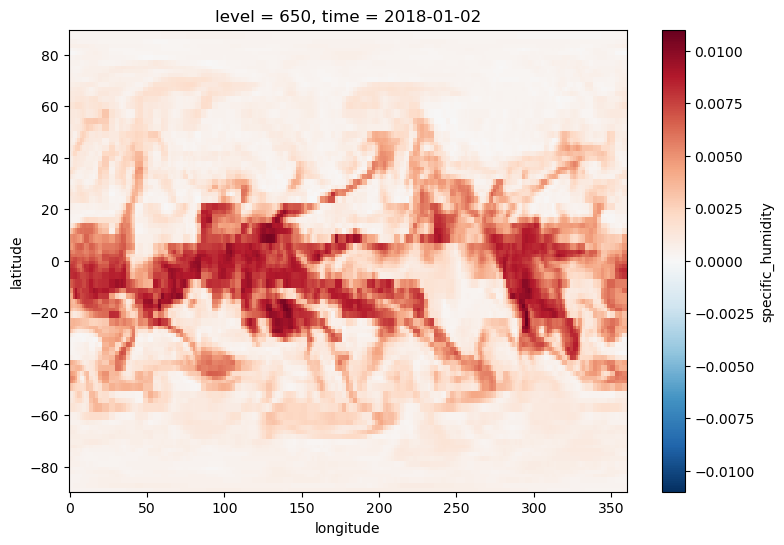

In [15]:
(1.2*data['specific_humidity'].isel(time=0).sel(level=650)).plot(x='longitude', figsize=(9,6))
# (
#     data['specific_humidity'].isel(time=0).sel(level=850)
#     +0.5*data['specific_humidity'].isel(time=1).sel(level=100)
# ).plot(x='longitude', figsize=(9,6))

Text(0.5, 1.0, '')

<Figure size 640x480 with 0 Axes>

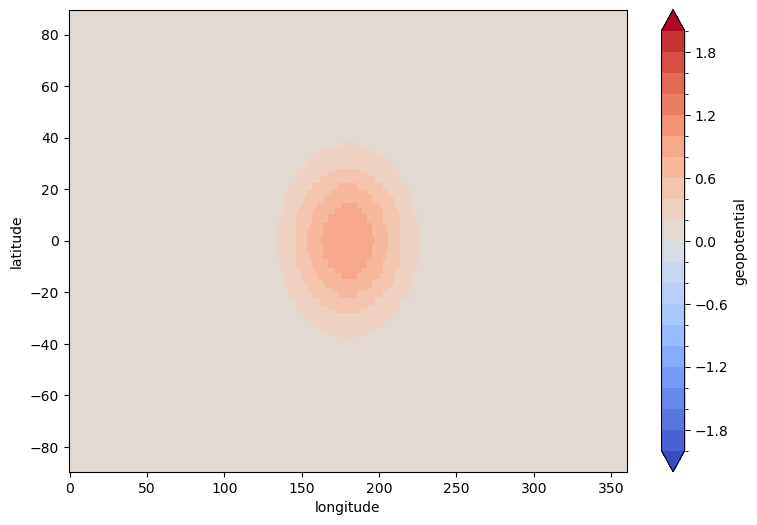

In [160]:
# plt.figure()
# mean_state = xr.zeros_like(data['geopotential'])
# mean_state[:] = 10*np.sin(mean_state.longitude/360)
# mean_state.isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-10, 10, 21), extend='both')
# plt.title('')

# plt.figure()
# evolved_state = xr.zeros_like(data['geopotential'])
# evolved_state[:] = 10*np.sin((evolved_state.longitude-120)/360)
# evolved_state.isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-10, 10, 21), extend='both')
# plt.title('')

# plt.figure()
# (evolved_state - mean_state).isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-4, 1, 21), extend='both')
# plt.title('')

plt.figure()
perturbation = xr.zeros_like(data['geopotential'])
perturbation[:] = 1*np.exp(-100*((perturbation.longitude-180)/360)**2)*np.exp(-150*(perturbation.latitude/360)**2)
perturbation.isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-2, 2, 21), extend='both')
plt.title('')

# plt.figure()
# (
#     evolved_state
#     + perturbation
#     - (evolved_state - mean_state)
#     - mean_state
# ).isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-4, 4, 21), extend='both')
# plt.title('')

# plt.figure()
# perturbed_mean_state = xr.zeros_like(data['geopotential'])
# perturbed_mean_state[:] = evolved_state + 2*np.cos((perturbed_mean_state.longitude+80)/360)*np.exp(-100*(perturbed_mean_state.latitude/360)**2) - mean_state
# perturbed_mean_state.isel(time=0).sel(level=650).plot(x='longitude', figsize=(9,6), cmap='coolwarm', levels=np.linspace(-10, 10, 21), extend='both')
# plt.title('')

In [23]:
# era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
# full_era5 = xr.open_zarr(
#     era5_path, chunks=None, storage_options=dict(token='anon')
# )

# data_inner_steps = 24
# # sliced_era5 = full_era5.pipe(
# #         xarray_utils.selective_temporal_shift,
# #         variables=full_era5.specific_humidity,
# #         time_shift='24 hours',
# #     ).sel(time=slice(demo_start_time, demo_end_time, data_inner_steps)).compute()

# inner_steps = 24  # save model outputs once every 24 hours
# outer_steps = 30 * 24 // inner_steps  # total of 4 days
# timedelta = np.timedelta64(1, 'h') * inner_steps
# times = (np.arange(outer_steps) * inner_steps)

# sliced_era5 = full_era5.sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
# sliced_era5['time'] = times

In [24]:
era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes['latitude'],
    longitude_nodes=full_era5.sizes['longitude'],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True
)
eval_era5 = xarray_utils.regrid(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

In [25]:
eval_era5

<xarray.Dataset> Size: 3GB
Dimensions:                                                          (time: 30,
                                                                      longitude: 256,
                                                                      latitude: 128,
                                                                      level: 37)
Coordinates:
  * level                                                            (level) int64 296B ...
  * time                                                             (time) int64 240B ...
  * longitude                                                        (longitude) float64 2kB ...
  * latitude                                                         (latitude) float64 1kB ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, longitude, latitude) float32 4MB ...
    100m_v_component_of_wind                                         (time, longitude, latitude) float32 4MB ...
    10m_u_component_of_neutral_wind                                  (time, longitude, latitude) float32 4MB ...
    10m_u_component_of_wind                                          (time, longitude, latitude) float32 4MB ...
    10m_v_component_of_neutral_wind                                  (time, longitude, latitude) float32 4MB ...
    10m_v_component_of_wind                                          (time, longitude, latitude) float32 4MB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, longitude, latitude) float32 4MB ...
    wave_spectral_directional_width_for_wind_waves                   (time, longitude, latitude) float32 4MB ...
    wave_spectral_kurtosis                                           (time, longitude, latitude) float32 4MB ...
    wave_spectral_peakedness                                         (time, longitude, latitude) float32 4MB ...
    wave_spectral_skewness                                           (time, longitude, latitude) float32 4MB ...
    zero_degree_level                                                (time, longitude, latitude) float32 4MB ...

In [8]:
data = xr.load_dataset("/glade/campaign/univ/uwas0152/2018-01-01_deterministic_cf.nc")
data

<xarray.Dataset> Size: 1GB
Dimensions:                              (longitude: 256, latitude: 128,
                                          level: 37, time: 30)
Coordinates:
  * longitude                            (longitude) float64 2kB 0.0 ... 358.6
  * latitude                             (latitude) float64 1kB -88.93 ... 88.93
  * level                                (level) int32 148B 1 2 3 ... 975 1000
  * time                                 (time) int32 120B 0 24 48 ... 672 696
Data variables:
    u_component_of_wind                  (time, level, longitude, latitude) float32 145MB ...
    specific_cloud_liquid_water_content  (time, level, longitude, latitude) float32 145MB ...
    v_component_of_wind                  (time, level, longitude, latitude) float32 145MB ...
    geopotential                         (time, level, longitude, latitude) float32 145MB ...
    temperature                          (time, level, longitude, latitude) float32 145MB ...
    specific_humidity                    (time, level, longitude, latitude) float32 145MB ...
    specific_cloud_ice_water_content     (time, level, longitude, latitude) float32 145MB ...
    sim_time                             (time) float32 120B 1.795e+05 ... 1....
Attributes:
    longitude_wavenumbers:     128
    total_wavenumbers:         129
    longitude_nodes:           256
    latitude_nodes:            128
    latitude_spacing:          gauss
    longitude_offset:          0.0
    radius:                    1.0
    spherical_harmonics_impl:  RealSphericalHarmonicsWithZeroImag
    spmd_mesh:                 
    centers:                   [   1    2    3    5    7   10   20   30   50 ...
    horizontal_grid_type:      Grid
    vertical_grid_type:        PressureCoordinates

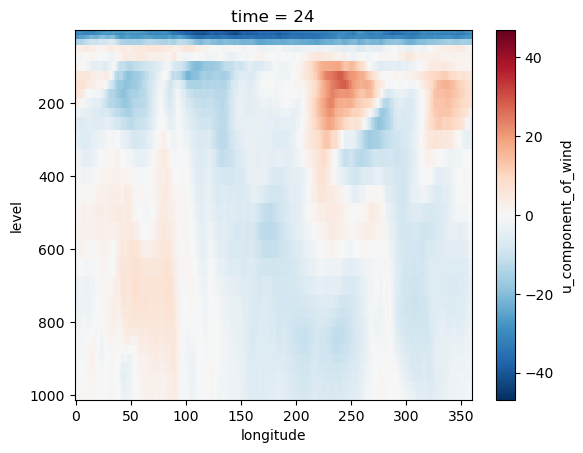

In [18]:
import matplotlib.pyplot as plt
data['u_component_of_wind'].sel(latitude=slice(-10, 10)).mean(dim='latitude').isel(time=1).plot(y='level')
plt.gca().invert_yaxis()
plt.show()

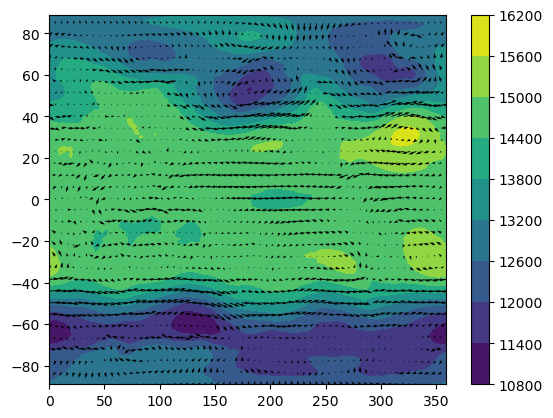

In [23]:
plt.figure()
plt.contourf(
    data['temperature'].longitude,
    data['temperature'].latitude,
    data['geopotential'].sel(level=850).mean(dim='time').T
)
plt.colorbar()

plt.quiver(
    data['temperature'].longitude[::4],
    data['temperature'].latitude[::4],
    data['u_component_of_wind'].sel(level=850).mean(dim='time').T[::4, ::4],
    data['v_component_of_wind'].sel(level=850).mean(dim='time').T[::4, ::4],
)

plt.show()

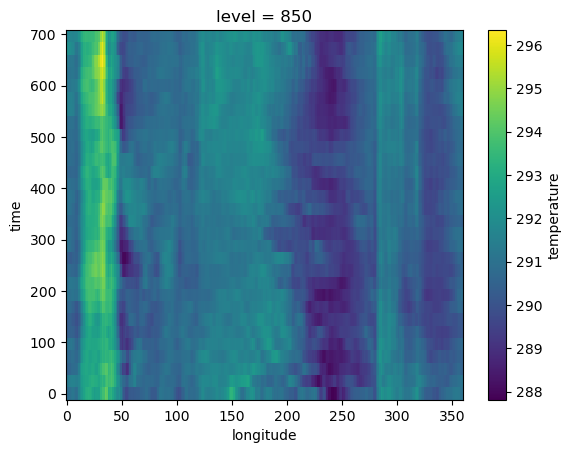

In [24]:
 data['temperature'].sel(latitude=slice(-5,5)).mean(dim='latitude').sel(level=850).plot(x='longitude')

In [26]:
 data['temperature'].sel(latitude=slice(-5,5)).mean(dim='latitude').sel(level=850).time

<xarray.DataArray 'time' (time: 30)> Size: 120B
array([  0,  24,  48,  72,  96, 120, 144, 168, 192, 216, 240, 264, 288, 312,
       336, 360, 384, 408, 432, 456, 480, 504, 528, 552, 576, 600, 624, 648,
       672, 696], dtype=int32)
Coordinates:
    level    int32 4B 850
  * time     (time) int32 120B 0 24 48 72 96 120 144 ... 576 600 624 648 672 696

In [1]:
import xarray as xr
era5_path = 'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3'
full_era5 = xr.open_zarr(
    era5_path, chunks=None, storage_options=dict(token='anon')
)

In [2]:
full_era5

<xarray.Dataset> Size: 4PB
Dimensions:                                                          (
                                                                      time: 1323648,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * latitude                                                         (latitude) float32 3kB ...
  * level                                                            (level) int64 296B ...
  * longitude                                                        (longitude) float32 6kB ...
  * time                                                             (time) datetime64[ns] 11MB ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 5TB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 5TB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 5TB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 5TB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 5TB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 5TB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 5TB ...
    zero_degree_level                                                (time, latitude, longitude) float32 5TB ...
Attributes:
    last_updated:           2025-06-30 01:47:00.511182+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-02-28
    valid_time_stop_era5t:  2025-06-24

In [46]:
demo_start_time = '2018-01-01'
demo_end_time = '2018-01-30'
data_inner_steps = 24
# sliced_era5 = full_era5.pipe(
#         xarray_utils.selective_temporal_shift,
#         variables=full_era5.specific_humidity,
#         time_shift='24 hours',
#     ).sel(time=slice(demo_start_time, demo_end_time, data_inner_steps)).compute()

import numpy as np
inner_steps = 24  # save model outputs once every 24 hours
outer_steps = 30 * 24 // inner_steps  # total of 4 days
timedelta = np.timedelta64(1, 'h') * inner_steps
times = (np.arange(outer_steps) * inner_steps)

sliced_era5 = full_era5.sel(time=slice(demo_start_time, demo_end_time, data_inner_steps))
sliced_era5['time'] = times

In [47]:
sliced_era5

<xarray.Dataset> Size: 83GB
Dimensions:                                                          (time: 30,
                                                                      latitude: 721,
                                                                      longitude: 1440,
                                                                      level: 37)
Coordinates:
  * latitude                                                         (latitude) float32 3kB ...
  * level                                                            (level) int64 296B ...
  * longitude                                                        (longitude) float32 6kB ...
  * time                                                             (time) int64 240B ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, latitude, longitude) float32 125MB ...
    100m_v_component_of_wind                                         (time, latitude, longitude) float32 125MB ...
    10m_u_component_of_neutral_wind                                  (time, latitude, longitude) float32 125MB ...
    10m_u_component_of_wind                                          (time, latitude, longitude) float32 125MB ...
    10m_v_component_of_neutral_wind                                  (time, latitude, longitude) float32 125MB ...
    10m_v_component_of_wind                                          (time, latitude, longitude) float32 125MB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, latitude, longitude) float32 125MB ...
    wave_spectral_directional_width_for_wind_waves                   (time, latitude, longitude) float32 125MB ...
    wave_spectral_kurtosis                                           (time, latitude, longitude) float32 125MB ...
    wave_spectral_peakedness                                         (time, latitude, longitude) float32 125MB ...
    wave_spectral_skewness                                           (time, latitude, longitude) float32 125MB ...
    zero_degree_level                                                (time, latitude, longitude) float32 125MB ...
Attributes:
    last_updated:           2025-06-30 01:47:00.511182+00:00
    valid_time_start:       1940-01-01
    valid_time_stop:        2025-02-28
    valid_time_stop_era5t:  2025-06-24

In [50]:
sliced_data = data.sel(level=850)
sliced_data['time'] = times

In [12]:
# data
eval_era5

<xarray.Dataset> Size: 658MB
Dimensions:                                                          (time: 30,
                                                                      longitude: 128,
                                                                      latitude: 64,
                                                                      level: 37)
Coordinates:
  * level                                                            (level) int64 296B ...
  * time                                                             (time) int64 240B ...
  * longitude                                                        (longitude) float64 1kB ...
  * latitude                                                         (latitude) float64 512B ...
Data variables: (12/273)
    100m_u_component_of_wind                                         (time, longitude, latitude) float32 983kB ...
    100m_v_component_of_wind                                         (time, longitude, latitude) float32 983kB ...
    10m_u_component_of_neutral_wind                                  (time, longitude, latitude) float32 983kB ...
    10m_u_component_of_wind                                          (time, longitude, latitude) float32 983kB ...
    10m_v_component_of_neutral_wind                                  (time, longitude, latitude) float32 983kB ...
    10m_v_component_of_wind                                          (time, longitude, latitude) float32 983kB ...
    ...                                                               ...
    wave_spectral_directional_width_for_swell                        (time, longitude, latitude) float32 983kB ...
    wave_spectral_directional_width_for_wind_waves                   (time, longitude, latitude) float32 983kB ...
    wave_spectral_kurtosis                                           (time, longitude, latitude) float32 983kB ...
    wave_spectral_peakedness                                         (time, longitude, latitude) float32 983kB ...
    wave_spectral_skewness                                           (time, longitude, latitude) float32 983kB ...
    zero_degree_level                                                (time, longitude, latitude) float32 983kB ...

In [81]:
era5_grid = spherical_harmonic.Grid(
    latitude_nodes=full_era5.sizes['latitude'],
    longitude_nodes=full_era5.sizes['longitude'],
    latitude_spacing=xarray_utils.infer_latitude_spacing(full_era5.latitude),
    longitude_offset=xarray_utils.infer_longitude_offset(full_era5.longitude),
)
regridder = horizontal_interpolation.ConservativeRegridder(
    era5_grid, model.data_coords.horizontal, skipna=True
)
eval_era5 = xarray_utils.regrid(sliced_era5, regridder)
eval_era5 = xarray_utils.fill_nan_with_nearest(eval_era5)

AttributeError: 'Dataset' object has no attribute 'data_coords'

In [26]:
combined_ds = xr.concat([eval_era5.transpose('time','latitude','longitude','level'), data.transpose('time','latitude','longitude','level')], 'model')
combined_ds.coords['model'] = ['ERA5', 'NeuralGCM']

In [31]:
combined_ds.longitude

<xarray.DataArray 'longitude' (longitude: 325)> Size: 3kB
array([  0.     ,   1.40625,   2.8125 , ..., 357.1875 , 357.1875 , 358.59375])
Coordinates:
  * longitude  (longitude) float64 3kB 0.0 1.406 2.812 ... 357.2 357.2 358.6

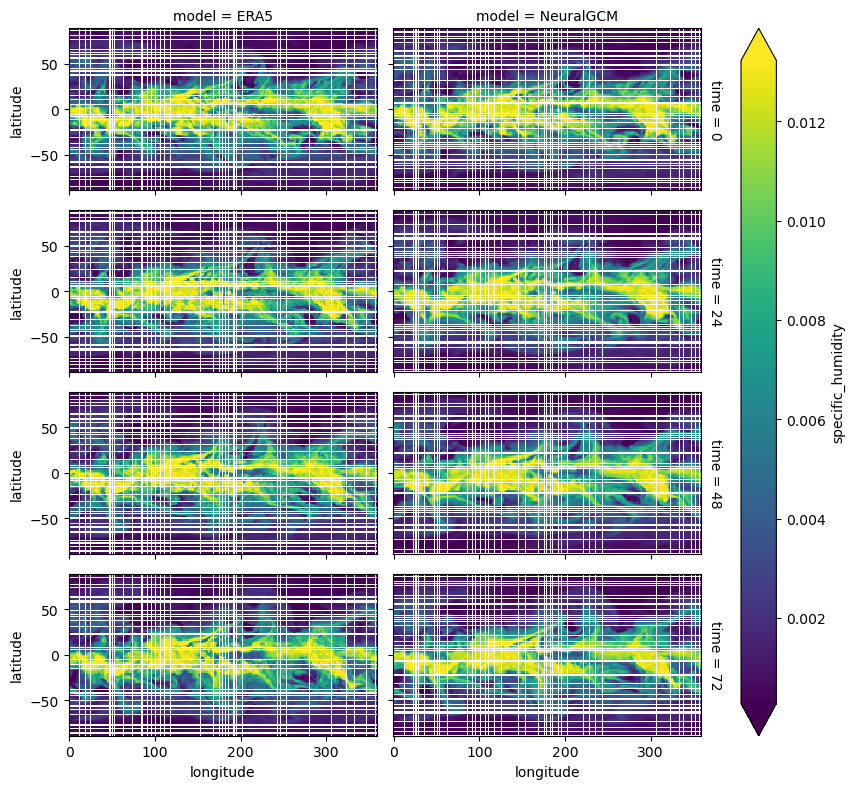

In [27]:
combined_ds.specific_humidity.isel(time=slice(0,4)).sel(level=850).plot(
    x='longitude', y='latitude', row='time', col='model', robust=True, aspect=2, size=2
);

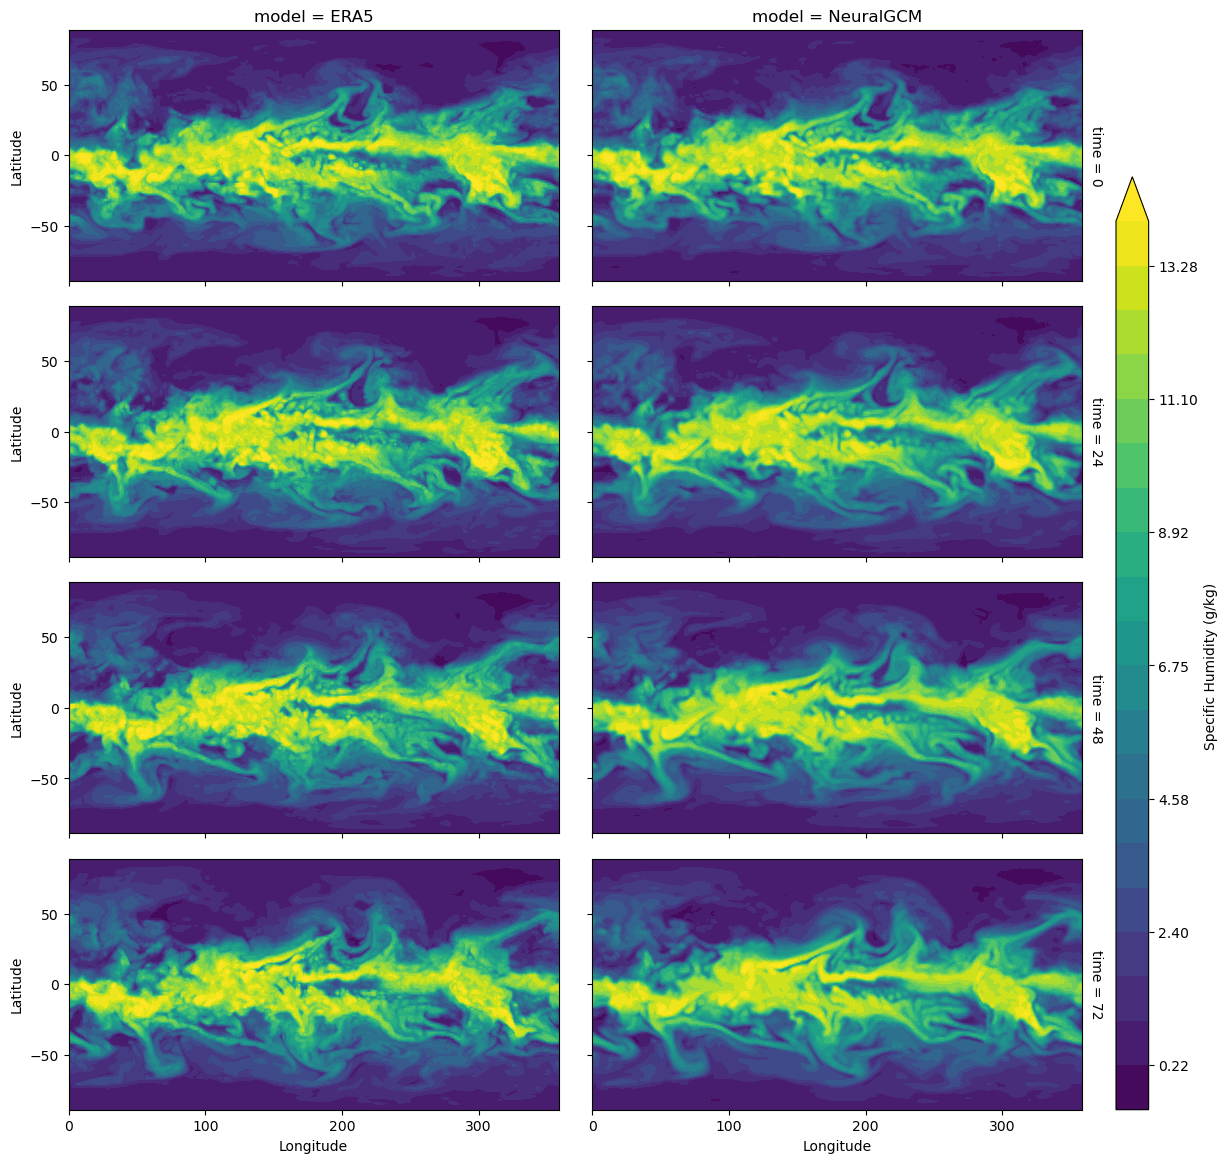

In [73]:
from matplotlib import colors as mcolors
from matplotlib import ticker as mticker
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 12))
gs = GridSpec(4, 3, figure=fig, width_ratios = [30, 30, 2])
gs.update(top=0.95, bottom=0.05, left=0.05, right=0.95, hspace=0.1, wspace=0.1)

left_ax = []
left_ax.append(fig.add_subplot(gs[0, 0]))
left_ax.append(fig.add_subplot(gs[1, 0]))
left_ax.append(fig.add_subplot(gs[2, 0]))
left_ax.append(fig.add_subplot(gs[3, 0]))

right_ax = []
right_ax.append(fig.add_subplot(gs[0, 1]))
right_ax.append(fig.add_subplot(gs[1, 1]))
right_ax.append(fig.add_subplot(gs[2, 1]))
right_ax.append(fig.add_subplot(gs[3, 1]))

cbar_axis = fig.add_subplot(gs[:, -1])

levels = np.linspace(-0.5, 14, 21)


left_ax[0].set_title('model = ERA5')
right_ax[0].set_title('model = NeuralGCM')
for index, time in enumerate(range(0, 4, 1)):
    left_ax[index].contourf(
        eval_era5.longitude,
        eval_era5.latitude,
        1000*eval_era5.specific_humidity.sel(time=times[time]).sel(level=850).T,
        levels=levels,
        extend='max',
        cmap='viridis'
    )
    left_ax[index].set_ylabel('Latitude')
    left_ax[index].set_yticks([-50, 0, 50])
    left_ax[index].set_xticks([0, 100, 200, 300], labels=[])
    im = right_ax[index].contourf(
        data.longitude,
        data.latitude,
        1000*data.specific_humidity.sel(time=times[time]).sel(level=850).T,
        levels=levels,
        extend='max',
        cmap='viridis'
    )
    right_ax[index].yaxis.set_label_position("right")
    right_ax[index].set_yticks([-50, 0, 50], labels=[])
    right_ax[index].set_xticks([0, 100, 200, 300], labels=[])
    right_ax[index].set_ylabel(f"time = {times[time]}", rotation=270, labelpad=15)
    cbar = fig.colorbar(im, cax=cbar_axis)
    cbar.set_label('Specific Humidity (g/kg)')

left_ax[3].set_xlabel('Longitude')
right_ax[3].set_xlabel('Longitude')
left_ax[3].set_xticks([0, 100, 200, 300], labels=[0, 100, 200, 300])
right_ax[3].set_xticks([0, 100, 200, 300], labels=[0, 100, 200, 300])

plt.show()

In [80]:
# # print(data.dims)
# # print(eval_era5.dims)

# test = data.isel(time=0)
# test

model.inputs_from_xarray(eval_era5.isel(time=0))

# data

UFuncTypeError: ufunc 'subtract' cannot use operands with types dtype('int64') and dtype('<M8[h]')

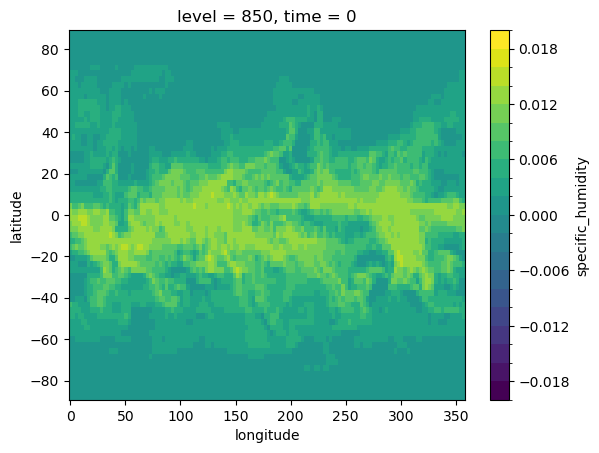

In [18]:
eval_era5.specific_humidity.isel(time=0).sel(level=850).plot(x='longitude', y='latitude', cmap='viridis', levels=np.linspace(-0.02, 0.02, 21))